# Economics 5040 - Week 2
## Starter Notebook

Expected Utility and Asset Pricing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import matrix_rank, lstsq

# Problem 1. CARA Utility and the Price of Risk

Write your derivations and economic explanations in Markdown cells.

### (a)
Derive $A(w)$ and $\rho(w)$, and explain the name.

With $u(w) = \dfrac{1 - e^{-\gamma w}}{\gamma}$,

$$
u'(w) = e^{-\gamma w}, \qquad u''(w) = -\gamma e^{-\gamma w},
$$

so

$$
A(w) = -\frac{u''(w)}{u'(w)} = \frac{\gamma e^{-\gamma w}}{e^{-\gamma w}} = \gamma,
\qquad
\rho(w) = -\frac{w\,u''(w)}{u'(w)} = \gamma w .
$$

$A(w)$ is the same number at every wealth level, which is exactly what "constant absolute risk aversion" names. The practical content: this agent's willingness to take a gamble denominated in *dollars* does not depend on how rich they are. A \$100 bet is evaluated identically at $w = 1{,}000$ and at $w = 1{,}000{,}000$, so wealth effects on risk taking are switched off.

Relative risk aversion is not constant, though. $\rho(w) = \gamma w$ grows without bound, so a richer CARA agent becomes more and more averse to gambles denominated in *percentages* of wealth. That is the empirically awkward side of CARA, and it is what makes the Devil's Offer in (d) work.

In [2]:
gamma = 1/1000
w0 = 30000.0

def cara(w, gamma):
    # (1 - exp(-gamma w))/gamma, via expm1 so it stays accurate when gamma*w is small
    return -np.expm1(-gamma * np.asarray(w, dtype=float)) / gamma

def ARA_cara(w, gamma):
    return np.full_like(np.asarray(w, dtype=float), gamma)

def RRA_cara(w, gamma):
    return gamma * np.asarray(w, dtype=float)

print(f"{'w':>10}{'A(w)':>10}{'rho(w)':>10}")
for w in (1_000.0, 30_000.0, 90_000.0):
    print(f"{w:>10,.0f}{ARA_cara(w, gamma):>10.6f}{RRA_cara(w, gamma):>10.2f}")

# check the analytics against finite differences. This has to be done at moderate
# wealth: by w = 30,000 the curve is flat to 13 digits and the second difference is
# all rounding error, which is the same trap that shows up in part (c).
h = 1e-3
print(f"\n{'w':>10}{'A(w)':>12}{'finite diff':>14}")
for w in (100.0, 500.0, 2_000.0):
    d1 = (cara(w + h, gamma) - cara(w - h, gamma)) / (2 * h)
    d2 = (cara(w + h, gamma) - 2 * cara(w, gamma) + cara(w - h, gamma)) / h**2
    print(f"{w:>10,.0f}{gamma:>12.6f}{-d2/d1:>14.6f}")

         w      A(w)    rho(w)
     1,000  0.001000      1.00
    30,000  0.001000     30.00
    90,000  0.001000     90.00

         w        A(w)   finite diff
       100    0.001000      0.001000
       500    0.001000      0.001000
     2,000    0.001000      0.001000


### (b)
Plot $u(w)$ on $[0,\,100{,}000]$ for $\gamma = 1/1000$, then compare curvature across several $\gamma$.

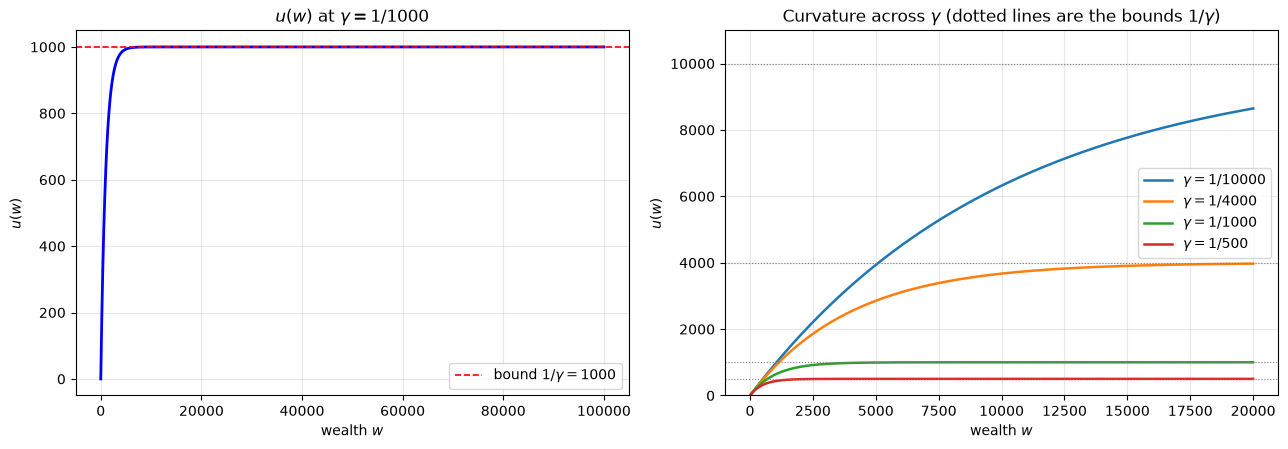

gamma = 1/10,000:  bound 1/gamma =   10,000,  99% of the bound reached at w =    46,052
gamma = 1/ 4,000:  bound 1/gamma =    4,000,  99% of the bound reached at w =    18,421
gamma = 1/ 1,000:  bound 1/gamma =    1,000,  99% of the bound reached at w =     4,605
gamma = 1/   500:  bound 1/gamma =      500,  99% of the bound reached at w =     2,303


In [3]:
w = np.linspace(0, 100_000, 1000)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

ax[0].plot(w, cara(w, gamma), lw=2, color="blue")
ax[0].axhline(1 / gamma, color="red", ls="--", lw=1.2, label=r"bound $1/\gamma = 1000$")
ax[0].set_title(r"$u(w)$ at $\gamma = 1/1000$")
ax[0].legend()

# Second panel: several gammas. u(0)=0 and u'(0)=1 for every gamma, so the curves
# all leave the origin on the same tangent and any difference is pure curvature.
w2 = np.linspace(0, 20_000, 1000)
for g in (1/10_000, 1/4_000, 1/1_000, 1/500):
    ax[1].plot(w2, cara(w2, g), lw=1.8, label=rf"$\gamma = 1/{1/g:.0f}$")
    ax[1].axhline(1 / g, color="gray", ls=":", lw=0.8)
ax[1].set_ylim(0, 11_000)
ax[1].set_title(r"Curvature across $\gamma$ (dotted lines are the bounds $1/\gamma$)")
ax[1].legend()

for a in ax:
    a.set_xlabel(r"wealth $w$")
    a.set_ylabel(r"$u(w)$")
    a.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

for g in (1/10_000, 1/4_000, 1/1_000, 1/500):
    # wealth at which utility is within 1% of its bound
    w99 = -np.log(0.01) / g
    print(f"gamma = 1/{1/g:>6,.0f}:  bound 1/gamma = {1/g:>8,.0f},  99% of the bound reached at w = {w99:>9,.0f}")

The left panel is the plot the question asks for, and on its own it is almost useless. With $\gamma = 1/1000$ utility is bounded by $1/\gamma = 1000$ and gets within 1% of that bound by $w \approx 4{,}600$, so across $[0,\,100{,}000]$ the picture is a spike followed by a flat line. Every economically interesting feature happens in the leftmost 5% of the axis.

Hence the second panel, and two choices behind it. First, the $\gamma$ values are spread over a factor of 20, because anything closer looks identical. Second, the range is $[0,\,20{,}000]$ rather than the full $[0,\,100{,}000]$: that window straddles the four bounds, so the $\gamma = 1/10{,}000$ curve is still visibly climbing at the right edge while $\gamma = 1/500$ flattened out around $w = 2{,}000$. Widen the range and the three most curved cases collapse into indistinguishable horizontal lines.

One feature makes the comparison clean rather than arbitrary: $u(0) = 0$ and $u'(0) = 1$ for every $\gamma$. All four curves leave the origin along the same tangent, so everything you see after that is curvature rather than a difference in units.

### (c)
$w_0 = 30{,}000$, $\gamma = 1/1000$, and a 50–50 gamble that loses 100 or wins 110. Accept or refuse? Certainty equivalent and risk premium.

Accepting delivers $w_0 + X$ with $X \in \{-100,\,+110\}$ at even odds; refusing delivers $w_0$ for sure.

CARA gives a closed form for the certainty equivalent. Starting from $u(CE) = E[u(w_0 + X)]$ and cancelling $\gamma$,

$$
e^{-\gamma CE} = e^{-\gamma w_0}\, E\!\left[e^{-\gamma X}\right]
\qquad \Longrightarrow \qquad
CE = w_0 - \frac{1}{\gamma}\log E\!\left[e^{-\gamma X}\right].
$$

So the gamble is accepted if and only if $E[e^{-\gamma X}] < 1$, and $w_0$ drops out — the same test at any wealth.

In [4]:
X = np.array([-100.0, 110.0])
p = np.array([0.5, 0.5])

EU_accept = p @ cara(w0 + X, gamma)
U_refuse = cara(w0, gamma)

print(f"EU(accept) = {EU_accept:.10f}")
print(f"u(refuse)  = {U_refuse:.10f}")
print(f"difference = {EU_accept - U_refuse:.3e}")
print(f"float64 spacing near 1000 = {np.spacing(1000.0):.3e}  <- the gap above is one step of that")

# u is capped at 1/gamma = 1000 and exp(-gamma*w0) = exp(-30) ~ 1e-13, so both numbers sit
# ~1e-10 below the cap and the true gap is finer than the spacing. Factoring out
# exp(-gamma*w0) asks the same question exactly: accept iff E[exp(-gamma X)] < 1.
mgf = p @ np.exp(-gamma * X)
CE = w0 - np.log(mgf) / gamma
print(f"\nE[exp(-gamma X)] = {mgf:.10f}  ->  {'accept' if mgf < 1 else 'refuse'}")
print(f"true gap in utils = {-(np.exp(-gamma*w0)/gamma)*(mgf-1):.3e}   (vs the printed one above)")
print(f"\nCE of final wealth = {CE:,.4f}")
print(f"E[final wealth]    = {w0 + p @ X:,.4f}")
print(f"risk premium       = {w0 + p @ X - CE:,.4f}")

win_min = -np.log(2 - np.exp(gamma * 100)) / gamma
print(f"\nsmallest win that would be accepted against a loss of 100: {win_min:.4f}")

EU(accept) = 999.9999999999
u(refuse)  = 999.9999999999
difference = -1.137e-13
float64 spacing near 1000 = 1.137e-13  <- the gap above is one step of that

E[exp(-gamma X)] = 1.0005025267  ->  refuse
true gap in utils = -4.702e-14   (vs the printed one above)

CE of final wealth = 29,999.4976
E[final wealth]    = 30,005.0000
risk premium       = 5.5024

smallest win that would be accepted against a loss of 100: 111.1225


The two utility numbers agree to thirteen digits, and the difference that prints, $-1.14 \times 10^{-13}$, is exactly one step between representable doubles at that magnitude. The true gap is about $-4.7\times10^{-14}$, half a step, so the direct comparison is decided by rounding rather than by economics. That is not a knife-edge preference: $u$ is capped at 1000, $w_0 = 30{,}000$ leaves us $e^{-30} \approx 10^{-13}$ short of the cap, and everything interesting is happening below the resolution of float64. Comparing $E[e^{-\gamma X}]$ against 1 removes the common factor $e^{-\gamma w_0}$ and answers the question exactly.

$E[e^{-\gamma X}] = 1.000503 > 1$, so the gamble is refused. Final wealth has a certainty equivalent of \$29,999.50 against an expected value of \$30,005, so the risk premium is \$5.50 — more than the \$5 the gamble is worth in expectation, which is the same fact stated in dollars. The win would need to be at least 111.12 to change the decision.

Turning down a coin flip between $-\$100$ and $+\$110$ at a wealth of \$30,000 is a lot of aversion for so small a stake, and under CARA it happens at every wealth level, including \$30 million. This is the setup for Rabin's calibration critique.

### (d)
The Devil's Offer: all the wealth in the universe against a 50–50 chance of losing 1000, then 500.

"All the wealth in the universe" is the ceiling of the utility function:

$$
\lim_{w \to \infty} u(w) = \lim_{w \to \infty} \frac{1 - e^{-\gamma w}}{\gamma} = \frac{1}{\gamma} = 1000 .
$$

Infinite wealth buys a *finite* amount of utility, and that finiteness is what the whole problem turns on.

The offer is a 50–50 gamble between $w = \infty$ and $w_0 - L$, so it is accepted when

$$
\frac{1}{2}\cdot\frac{1}{\gamma} + \frac{1}{2}\cdot\frac{1 - e^{-\gamma(w_0 - L)}}{\gamma}
\;>\;
\frac{1 - e^{-\gamma w_0}}{\gamma}.
$$

Multiplying through by $\gamma$ and cancelling leaves $\tfrac12 e^{-\gamma(w_0-L)} < e^{-\gamma w_0}$, and $e^{-\gamma w_0}$ divides out:

$$
\tfrac{1}{2}e^{\gamma L} < 1
\qquad \Longleftrightarrow \qquad
L < \frac{\log 2}{\gamma} = 693.15 .
$$

Initial wealth cancelled, so the cutoff is the same for a pauper and a billionaire. A possible loss of 1000 is refused; a possible loss of 500 is accepted.

In [5]:
u_inf = 1 / gamma
print(f"lim u(w) as w -> infinity = 1/gamma = {u_inf:,.1f}")
print(f"u(w0) = {cara(w0, gamma):.10f}, so the whole remaining upside is worth "
      f"{u_inf - cara(w0, gamma):.3e} utils\n")

L_star = np.log(2) / gamma
for Ld in (1000.0, 500.0):
    EU = 0.5 * u_inf + 0.5 * cara(w0 - Ld, gamma)
    gap = EU - cara(w0, gamma)
    print(f"possible loss {Ld:>6,.0f}:  EU - u(w0) = {gap:+.3e}   "
          f"exp(gamma*L) = {np.exp(gamma*Ld):.6f} vs 2   ->  {'ACCEPT' if gap > 0 else 'REFUSE'}")

print(f"\ncutoff loss L* = log(2)/gamma = {L_star:.4f}")

# The criterion exp(gamma L) < 2 contains no w0. The direct utility comparison agrees
# wherever float64 can still resolve it, and goes silent once exp(-gamma*w0) underflows.
print(f"\nsame offer at L = 600 (below the cutoff, so it should always be accepted):")
print(f"{'w0':>16}{'exp(-gamma w0)':>18}{'EU - u(w0)':>16}{'exact test':>14}")
for wealth in (1_000.0, 10_000.0, 30_000.0, 1e9):
    EU = 0.5 * u_inf + 0.5 * cara(wealth - 600.0, gamma)
    verdict = "accept" if np.exp(gamma * 600.0) < 2 else "refuse"
    print(f"{wealth:>16,.0f}{np.exp(-gamma*wealth):>18.3e}{EU - cara(wealth, gamma):>16.3e}{verdict:>14}")

lim u(w) as w -> infinity = 1/gamma = 1,000.0
u(w0) = 999.9999999999, so the whole remaining upside is worth 9.356e-11 utils

possible loss  1,000:  EU - u(w0) = -3.354e-11   exp(gamma*L) = 2.718282 vs 2   ->  REFUSE
possible loss    500:  EU - u(w0) = +1.637e-11   exp(gamma*L) = 1.648721 vs 2   ->  ACCEPT

cutoff loss L* = log(2)/gamma = 693.1472

same offer at L = 600 (below the cutoff, so it should always be accepted):
              w0    exp(-gamma w0)      EU - u(w0)    exact test
           1,000         3.679e-01       3.272e+01        accept
          10,000         4.540e-05       4.038e-03        accept
          30,000         9.358e-14       8.299e-12        accept
   1,000,000,000         0.000e+00       0.000e+00        accept


At $L = 1000$ expected utility falls below $u(w_0)$, so the offer is refused even though the prize is unbounded wealth forever. At $L = 500$ it is accepted. Both agree with $e^{\gamma L}$ against 2.

The last table is the wealth-independence check, and it also shows where the arithmetic gives out. The criterion $e^{\gamma L} < 2$ has no $w_0$ in it, so $L = 600$ should be accepted by anyone. The direct utility comparison confirms this at \$1,000, \$10,000 and \$30,000, with the margin shrinking by roughly $e^{-\gamma w_0}$ each time, and then returns exactly zero at \$1 billion — there $e^{-\gamma w_0} = e^{-10^6}$ underflows to 0, $u(w_0)$ and $u(w_0 - L)$ both round to the cap of 1000, and float64 can no longer tell the two branches apart. The economics is unchanged; only the representation runs out. It is worth keeping in mind that a bounded utility function evaluated far from the origin destroys most of the information in the numbers.

### (e)
What the Devil's Offer teaches about CARA, and why bounded utility can make an unlimited upside insufficient.

Write both sides of the offer in utils. The most the upside can ever be worth is the distance from where you stand to the ceiling,

$$
\frac{1}{\gamma} - u(w_0) = \frac{e^{-\gamma w_0}}{\gamma},
$$

and no prize can beat that, because there is nothing above the ceiling. The downside has no such limit: losing $L$ costs

$$
u(w_0) - u(w_0 - L) = \frac{e^{-\gamma w_0}}{\gamma}\left(e^{\gamma L} - 1\right)
$$

utils, growing exponentially in $L$. Both expressions carry the same factor $e^{-\gamma w_0}/\gamma$, which is why wealth cancelled in (d), and the 50–50 comparison collapses to $e^{\gamma L} - 1$ against 1.

So the mechanism is: a finite maximum gain against an unbounded possible loss. Bounded utility is usually introduced as the *fix* for the St. Petersburg paradox, where it stops the expected utility of an unbounded prize from diverging. The Devil's Offer is the same property seen from the other side, and it is far less comfortable — once utility is bounded, there is always some finite loss so bad that no prize whatsoever compensates for a 50% chance of suffering it. Here that loss is \$693, which is not a large sum.

Underneath this is the relative risk aversion $\rho(w) = \gamma w$. As the Devil's prize makes you rich, your aversion to proportional risk grows without bound, so the marginal value of yet more wealth collapses. CARA is a convenient functional form for problems with additive risk, not a description of how anyone treats enormous stakes. A CRRA agent with $\rho < 1$ has unbounded utility and would take the offer at any $L$.

# Problem 2. From Outcomes to Expected Utility

Write your derivations and economic explanations in Markdown cells.

### (a)
Normalize $u(x_1) = 0$, $u(x_3) = 1$ and find the $q$ that makes $x_2$ for certain indifferent to the best–worst lottery.

A positive affine rescaling of a vNM index leaves choices unchanged, so set

$$
\hat{u}(x) = \frac{\log x - \log x_1}{\log x_3 - \log x_1}.
$$

Indifference between $x_2$ for sure and the lottery $(q \text{ on } x_3,\ 1-q \text{ on } x_1)$ means $\hat{u}(x_2) = q\cdot 1 + (1-q)\cdot 0 = q$. With these numbers the logs are convenient, since $x_3/x_1 = 9$ and $x_2/x_1 = 4$:

$$
q = \frac{\log 4}{\log 9} = \frac{2\log 2}{2 \log 3} = \frac{\log 2}{\log 3} = 0.630930 .
$$

$q$ exceeds $\tfrac12$ even though 100 sits below the midpoint of $[25, 225]$ in dollars. That is concavity: 100 is closer to 225 in utility than it is in money, so it takes better than even odds on the good outcome to match it.

In [6]:
x = np.array([25.0, 100.0, 225.0])
L = np.array([0.25, 0.50, 0.25])

u = np.log(x)
u_hat = (u - u[0]) / (u[2] - u[0])     # normalized so u(25)=0 and u(225)=1
q = u_hat[1]

print(f"{'x':>8}{'log x':>10}{'normalized':>13}")
for xi, ui, uh in zip(x, u, u_hat):
    print(f"{xi:>8.0f}{ui:>10.6f}{uh:>13.6f}")

print(f"\nq = log(4)/log(9) = log(2)/log(3) = {q:.10f}")
print(f"check: q*u_hat[2] + (1-q)*u_hat[0] = {q*u_hat[2] + (1-q)*u_hat[0]:.10f}  vs  u_hat[1] = {u_hat[1]:.10f}")
print(f"in dollars, x2 = 100 sits {(x[1]-x[0])/(x[2]-x[0]):.4f} of the way from x1 to x3")

       x     log x   normalized
      25  3.218876     0.000000
     100  4.605170     0.630930
     225  5.416100     1.000000

q = log(4)/log(9) = log(2)/log(3) = 0.6309297536
check: q*u_hat[2] + (1-q)*u_hat[0] = 0.6309297536  vs  u_hat[1] = 0.6309297536
in dollars, x2 = 100 sits 0.3750 of the way from x1 to x3


### (b)
Reduce $L = (0.25, 0.50, 0.25)$ to a lottery over $x_1$ and $x_3$ only, and check the weight on $x_3$ against expected normalized utility.

Replace the $x_2$ branch by its indifferent best–worst lottery and collapse the compound lottery. The total weight landing on $x_3$ is

$$
0.25(0) + 0.50(q) + 0.25(1) = 0.5q + 0.25 = 0.565465,
$$

which is precisely $E_L[\hat{u}]$, since $\hat{u}$ takes the values $0, q, 1$. That identity is not a coincidence — normalizing to $[0,1]$ makes expected utility *equal* the probability of the best outcome in the equivalent two-point lottery, which is what makes the index interpretable.

In [7]:
p3 = 0.25 * 0 + 0.50 * q + 0.25 * 1     # weight on x3 after collapsing the compound lottery
print(f"reduced lottery:  {1-p3:.6f} on x1 = 25,  {p3:.6f} on x3 = 225")
print(f"E_L[u_hat]     =  {L @ u_hat:.6f}")
print(f"difference     =  {abs(p3 - L @ u_hat):.3e}")

# same thing in raw log units, then renormalized
print(f"\nE_L[log c] = {L @ u:.6f}  ->  renormalized {(L @ u - u[0]) / (u[2] - u[0]):.6f}")
print(f"E_L[c]     = {L @ x:.4f},  certainty equivalent = {np.exp(L @ u):.4f}")

reduced lottery:  0.434535 on x1 = 25,  0.565465 on x3 = 225
E_L[u_hat]     =  0.565465
difference     =  0.000e+00

E_L[log c] = 4.461329  ->  renormalized 0.565465
E_L[c]     = 112.5000,  certainty equivalent = 86.6025


### (c)
Build a second lottery $M$, rank $L$ and $M$, and check that a positive affine transformation preserves the ranking.

Take $M$ to put all its weight on the extremes while keeping the expected payoff of $L$ unchanged. Solving $25p + 225(1-p) = 112.5$ gives $p = 0.5625$, so

$$
M = (0.5625,\ 0,\ 0.4375).
$$

$M$ is a mean-preserving spread of $L$, which makes the comparison informative rather than arbitrary: the two lotteries are indistinguishable to a risk-neutral agent, so whatever ranks them here is risk aversion and nothing else.

For the transformation take $v = 5\hat{u} + 2$. Since $E[v] = 5E[\hat{u}] + 2$ is increasing in $E[\hat{u}]$, the ranking cannot change; the numbers move but their order does not.

In [8]:
M = np.array([0.5625, 0.0, 0.4375])     # same expected payoff as L, weight on the extremes

print(f"E[c]:      L = {L @ x:.4f}    M = {M @ x:.4f}    (equal by construction)")
print(f"E[u_hat]:  L = {L @ u_hat:.6f}    M = {M @ u_hat:.6f}    ->  L preferred")

a, b = 5.0, 2.0
v = a * u_hat + b
print(f"\nafter v = {a:.0f}*u_hat + {b:.0f}:")
print(f"E[v]:      L = {L @ v:.6f}    M = {M @ v:.6f}    ->  L preferred")
print(f"gap scales by exactly a: {(L @ v - M @ v) / (L @ u_hat - M @ u_hat):.6f}")

E[c]:      L = 112.5000    M = 112.5000    (equal by construction)
E[u_hat]:  L = 0.565465    M = 0.437500    ->  L preferred

after v = 5*u_hat + 2:
E[v]:      L = 4.827324    M = 4.187500    ->  L preferred
gap scales by exactly a: 5.000000


### (d)
Apply a strictly increasing, non-affine transformation to the utility index and show the ranking can flip.

Take $\varphi(u) = u^3$, strictly increasing on $[0,1]$ and strictly convex. Applying it to the *index* (not to the payoffs) gives values $0,\ q^3,\ 1$, and

$$
E_L[\varphi] = 0.5\,q^3 + 0.25 = 0.375578,
\qquad
E_M[\varphi] = 0.4375,
$$

so $M \succ L$ under $\varphi$ while $L \succ M$ under $\hat{u}$. The ranking reverses.

The reason it can reverse is that expected utility compares *averages* of the index, an operation that is linear in probabilities, and only affine maps commute with taking averages: $E[a u + b] = a E[u] + b$, but $E[u^3] \neq (E[u])^3$. Curving the index therefore changes how the agent trades off spread, and here the convex $\varphi$ rewards $M$'s extra dispersion enough to overturn the original ranking.

This is the sharp contrast with ordinal utility under certainty. There we only ever compare $u$ at two sure outcomes, so any strictly increasing relabelling leaves every comparison intact — as with $\exp(\cdot)$ applied to $\log c_0 + \beta \log c_1$ in Problem Set 1. Once probabilities enter, the index carries cardinal information about *differences* between outcomes, and it is pinned down only up to a positive affine transformation.

In [9]:
phi = u_hat ** 3      # strictly increasing on [0,1], but convex rather than affine

print(f"{'':<12}{'E[u_hat]':>12}{'E[u_hat^3]':>14}")
print(f"{'L':<12}{L @ u_hat:>12.6f}{L @ phi:>14.6f}")
print(f"{'M':<12}{M @ u_hat:>12.6f}{M @ phi:>14.6f}")
print(f"\nunder u_hat:    {'L > M' if L @ u_hat > M @ u_hat else 'M > L'}")
print(f"under u_hat^3:  {'L > M' if L @ phi > M @ phi else 'M > L'}   <- reversed")

# the failure is that averaging and cubing do not commute
print(f"\nE[u_hat]^3 = {(L @ u_hat)**3:.6f}  but  E[u_hat^3] = {L @ phi:.6f}")

                E[u_hat]    E[u_hat^3]
L               0.565465      0.375578
M               0.437500      0.437500

under u_hat:    L > M
under u_hat^3:  M > L   <- reversed

E[u_hat]^3 = 0.180808  but  E[u_hat^3] = 0.375578


# Problem 3. State Prices and Arrow Securities

Write your derivations and economic explanations in Markdown cells.

### (a)
Derive and compute the state prices $q_H$ and $q_L$ from the consumer's first-order conditions.

The consumer can buy $z_s$ units of the Arrow security for state $s$ at price $q_s$, so

$$
\max_{z_H, z_L}\ \log\!\Big(c_0 - \sum_s q_s z_s\Big) + \beta \sum_s \pi_s \log\big(c_1(s) + z_s\big).
$$

The first-order condition for $z_s$, evaluated at the endowment where $z_s = 0$, is

$$
q_s\, u'(c_0) = \beta \pi_s u'(c_1(s))
\qquad \Longrightarrow \qquad
q_s = \beta \pi_s \frac{u'(c_1(s))}{u'(c_0)} = \beta \pi_s \frac{c_0}{c_1(s)} .
$$

The state price is the marginal rate of substitution between a dollar today and a dollar delivered in state $s$: discounting $\beta$, the odds $\pi_s$, and the relative scarcity of consumption in that state. Numerically,

$$
q_H = 0.96(0.5)\frac{10}{15} = 0.32,
\qquad
q_L = 0.96(0.5)\frac{10}{5} = 0.96 .
$$

In [10]:
beta = 0.96
pi = np.array([0.5, 0.5])
c0 = 10.0
c1 = np.array([15.0, 5.0])  # H, L

m = beta * (c0 / c1)        # SDF: beta * u'(c1)/u'(c0) under log utility
q = pi * m

print(f"{'state':<8}{'pi':>8}{'c1':>8}{'u1(c1)':>12}{'m':>10}{'q':>10}")
for s, lab in enumerate(["H", "L"]):
    print(f"{lab:<8}{pi[s]:>8.2f}{c1[s]:>8.1f}{1/c1[s]:>12.6f}{m[s]:>10.4f}{q[s]:>10.4f}")

print(f"\nq_H = {q[0]:.4f},  q_L = {q[1]:.4f},  q_H + q_L = {q.sum():.4f}")

state         pi      c1      u1(c1)         m         q
H           0.50    15.0    0.066667    0.6400    0.3200
L           0.50     5.0    0.200000    1.9200    0.9600

q_H = 0.3200,  q_L = 0.9600,  q_H + q_L = 1.2800


### (b)
Why is $q_L > q_H$ with equally likely states? Compute and interpret $q_s/\pi_s$.

In [11]:
print(f"q_L / q_H          = {q[1]/q[0]:.4f}")
print(f"u'(c_L) / u'(c_H)  = {(1/c1[1])/(1/c1[0]):.4f}   <- same number\n")

print(f"{'state':<8}{'q_s':>10}{'pi_s':>8}{'q_s/pi_s':>12}{'m_s':>10}")
for s, lab in enumerate(["H", "L"]):
    print(f"{lab:<8}{q[s]:>10.4f}{pi[s]:>8.2f}{q[s]/pi[s]:>12.4f}{m[s]:>10.4f}")

q_L / q_H          = 3.0000
u'(c_L) / u'(c_H)  = 3.0000   <- same number

state          q_s    pi_s    q_s/pi_s       m_s
H           0.3200    0.50      0.6400    0.6400
L           0.9600    0.50      1.9200    1.9200


Equal probabilities do not mean equal prices, because a state price is a probability multiplied by a marginal valuation. Consumption in $L$ is 5 against 15 in $H$, so marginal utility there is three times as high, and a claim paying one unit in $L$ is worth three times a claim paying one unit in $H$. The probabilities cancel out of the ratio entirely:

$$
\frac{q_L}{q_H} = \frac{u'(c_1(L))}{u'(c_1(H))} = \frac{c_1(H)}{c_1(L)} = 3 .
$$

Dividing out the probability isolates that valuation: $q_s/\pi_s = \beta u'(c_1(s))/u'(c_0)$, which is the stochastic discount factor $m_s$. Read it as the price of a claim per unit of probability, or as the price of a state-contingent dollar after correcting for how often the state occurs. Here $q_H/\pi_H = 0.64$ and $q_L/\pi_L = 1.92$.

The gap is what makes this an economy where risk is priced. If $c_1(H) = c_1(L)$, then $m_H = m_L$, state prices would be proportional to probabilities, and every asset would earn the same expected return. Everything in Problems 4 and 5 comes from the fact that $m$ varies across states.

### (c)
Hold $c_0$ and $c_1(H)$ fixed, vary $c_1(L)$ from 2 to 15, and plot $q_L/q_H$.

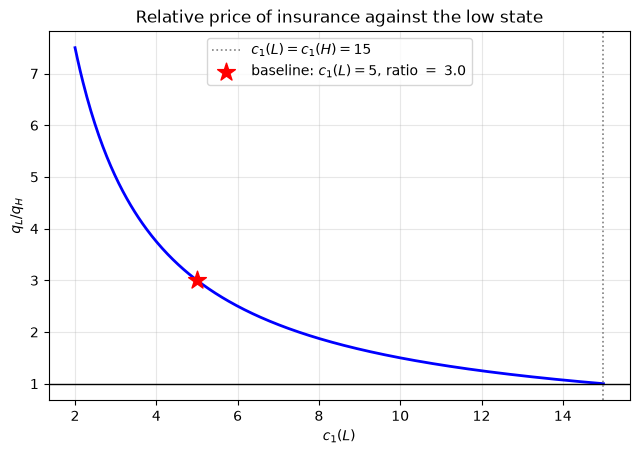

c1(L) =   2.0:  q_L/q_H = 7.5000
c1(L) =   5.0:  q_L/q_H = 3.0000
c1(L) =  10.0:  q_L/q_H = 1.5000
c1(L) =  15.0:  q_L/q_H = 1.0000


In [12]:
cL_grid = np.linspace(2, 15, 400)
ratio = (pi[1] / cL_grid) / (pi[0] / c1[0])     # = c1(H)/c1(L) when the two states are equally likely

plt.figure(figsize=(7.5, 4.8))
plt.plot(cL_grid, ratio, lw=2, color="blue")
plt.axhline(1, color="black", lw=1)
plt.axvline(c1[0], color="gray", ls=":", lw=1.2, label=r"$c_1(L) = c_1(H) = 15$")
plt.scatter([c1[1]], [q[1]/q[0]], color="red", marker="*", s=180, zorder=5,
            label=rf"baseline: $c_1(L)=5$, ratio $=$ {q[1]/q[0]:.1f}")
plt.xlabel(r"$c_1(L)$")
plt.ylabel(r"$q_L / q_H$")
plt.title(r"Relative price of insurance against the low state")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for cL in (2, 5, 10, 15):
    print(f"c1(L) = {cL:>5.1f}:  q_L/q_H = {c1[0]/cL:.4f}")

The curve is the hyperbola $q_L/q_H = c_1(H)/c_1(L) = 15/c_1(L)$, falling from 7.5 at $c_1(L) = 2$ to exactly 1 at $c_1(L) = 15$.

It is the price of insurance, and it is governed by how bad the bad state is. When $c_1(L) = 2$ the household is desperate in that state, marginal utility there is enormous, and it will pay 7.5 times as much for a dollar delivered in $L$ as for one delivered in $H$ — even though both are equally likely. As $c_1(L)$ rises the bad state stops being bad, the marginal utilities converge, and the premium melts away. At $c_1(L) = 15$ there is no risk left to insure and the ratio hits 1: with $\pi_H = \pi_L$ the state prices are equal and the household is indifferent about which state pays.

The convexity matters too. The curve is much steeper on the left, so the price of insurance rises far faster as the bad state deepens than it falls as the bad state improves. That is diminishing marginal utility showing up directly in a price.

### (d)
Compute the stochastic discount factor in each state and verify $q_s = \pi_s m_s$.

In [13]:
m_check = beta * (1/c1) / (1/c0)      # beta * u'(c1(s)) / u'(c0), written out

print(f"{'state':<8}{'m_s':>10}{'pi_s*m_s':>12}{'q_s':>10}{'|diff|':>12}")
for s, lab in enumerate(["H", "L"]):
    print(f"{lab:<8}{m_check[s]:>10.4f}{pi[s]*m_check[s]:>12.4f}{q[s]:>10.4f}{abs(pi[s]*m_check[s]-q[s]):>12.3e}")

print(f"\nE[m]   = {pi @ m:.4f}   and   q_H + q_L = {q.sum():.4f}   (same number)")
print(f"1/E[m] = {1/(pi @ m):.6f}   <- the risk-free gross return, used in Problem 4")

state          m_s    pi_s*m_s       q_s      |diff|
H           0.6400      0.3200    0.3200   5.551e-17
L           1.9200      0.9600    0.9600   0.000e+00

E[m]   = 1.2800   and   q_H + q_L = 1.2800   (same number)
1/E[m] = 0.781250   <- the risk-free gross return, used in Problem 4


$m_H = 0.64$ and $m_L = 1.92$, and $\pi_s m_s$ reproduces the state prices exactly. The decomposition separates two things that the state price mixes together: $\pi_s$ is how likely the state is, $m_s$ is how much the household values a dollar there. Only the second reflects preferences, and only the second is what the rest of this problem set prices.

Note also $E[m] = 1.28 = q_H + q_L$, which is the price of a claim that pays one unit in every state. Its reciprocal is the risk-free rate.

# Problem 4. Assets as Bundles of State-Contingent Claims

Write your derivations and economic explanations in Markdown cells.

### (a)
Price each asset with the state prices.

An asset is just a bundle of Arrow securities, so its price is the value of that bundle:

$$
p(x) = q_H x_H + q_L x_L = \sum_s q_s x_s .
$$

No new theory is needed — pricing is linear, so once the two state prices are known every payoff in the economy is priced by a dot product.

In [14]:
assets = {
    "A": np.array([1.0, 1.0]),
    "B": np.array([2.0, 0.0]),
    "C": np.array([0.0, 2.0]),
    "D": np.array([3.0, 1.0]),
}

def price(x):
    return q @ x

def show(x):
    return f"({x[0]:g}, {x[1]:g})"

print(f"{'asset':<7}{'(x_H, x_L)':>12}{'price':>10}")
for name, x_a in assets.items():
    print(f"{name:<7}{show(x_a):>12}{price(x_a):>10.4f}")

asset    (x_H, x_L)     price
A            (1, 1)    1.2800
B            (2, 0)    0.6400
C            (0, 2)    1.9200
D            (3, 1)    1.9200


$C$ costs three times $B$ despite paying the same 2 units, and $D$ costs the same as $C$ despite promising twice the expected payoff. Everything here comes from *where* the payoff lands, not how big it is.

### (b)
State-contingent gross returns and expected gross return.

In [15]:
def gross_returns(x):
    return x / price(x)

print(f"{'asset':<7}{'price':>9}{'R_H':>10}{'R_L':>10}{'E[R]':>10}{'E[x]':>9}")
for name, x_a in assets.items():
    R = gross_returns(x_a)
    print(f"{name:<7}{price(x_a):>9.4f}{R[0]:>10.4f}{R[1]:>10.4f}{pi @ R:>10.4f}{pi @ x_a:>9.2f}")

asset      price       R_H       R_L      E[R]     E[x]
A         1.2800    0.7813    0.7813    0.7813     1.00
B         0.6400    3.1250    0.0000    1.5625     1.00
C         1.9200    0.0000    1.0417    0.5208     1.00
D         1.9200    1.5625    0.5208    1.0417     2.00


$B$ and $C$ have identical expected payoffs but expected returns of 1.5625 and 0.5208 — a factor of three apart, matching the ratio of their prices. Since the payoffs are fixed, expected return is entirely a statement about price.

### (c)
$A$ is risk free. Compute $R_f$ and verify $1/R_f = q_H + q_L$.

In [16]:
Rf = 1 / price(assets["A"])
print(f"R_f          = 1/p_A = {Rf:.6f}   (net rate {Rf-1:+.4%})")
print(f"1/R_f        = {1/Rf:.6f}")
print(f"q_H + q_L    = {q.sum():.6f}")
print(f"E[m]         = {pi @ m:.6f}")
print(f"|difference| = {abs(1/Rf - q.sum()):.3e}")

R_f          = 1/p_A = 0.781250   (net rate -21.8750%)
1/R_f        = 1.280000
q_H + q_L    = 1.280000
E[m]         = 1.280000
|difference| = 0.000e+00


$A$ pays one unit whatever happens, so its price is $q_H + q_L$ and its return is the same in both states: $R_f = 1/1.28 = 0.78125$. The identity $1/R_f = q_H + q_L = E[m]$ is definitional — buying the full set of Arrow securities *is* the risk-free bond.

The net rate is $-21.875\%$, which looks alarming but is the right answer here. The household expects consumption of 10 on average tomorrow against 10 today, with substantial risk attached, so it wants to save; with $\beta$ close to 1 and a strong precautionary motive coming from $m_L = 1.92$, the bond gets bid up above par. A negative risk-free rate is what an economy looks like when everyone wants to store value and nobody wants to borrow.

### (d)
Compare $B$ and $C$.

$B$ has by far the higher expected return, 1.5625 against 0.5208, and the reason is the state in which each pays rather than anything about their size or riskiness.

$B$ pays only in $H$, the state where consumption is 15 and an extra dollar is worth least. It is useless exactly when the household would most want the money, so nobody will pay much for it: $p_B = 0.64$ for an expected payoff of 1. Cheap today means a high expected return.

$C$ pays only in $L$, where consumption is 5 and marginal utility is triple. It is insurance, and it is expensive at $p_C = 1.92$ for the same expected payoff of 1. Its expected return of 0.5208 is not just low, it sits *below* the risk-free 0.78125 — the household accepts a worse expected outcome in exchange for the payoff arriving when it matters. A negative risk premium is the signature of a hedge.

Both assets are risky in the ordinary sense: each pays either 2 or 0. Only the direction of that risk relative to consumption separates them.

### (e)
Verify $p = E[mx]$ and $1 = E[mR]$ for all four assets.

In [17]:
print(f"{'asset':<7}{'p':>10}{'E[mx]':>10}{'|diff|':>11}{'E[mR]':>10}{'|diff|':>11}")
for name, x_a in assets.items():
    p_a, Emx = price(x_a), pi @ (m * x_a)
    EmR = pi @ (m * gross_returns(x_a))
    print(f"{name:<7}{p_a:>10.4f}{Emx:>10.4f}{abs(p_a-Emx):>11.3e}{EmR:>10.6f}{abs(1-EmR):>11.3e}")

asset           p     E[mx]     |diff|     E[mR]     |diff|
A          1.2800    1.2800  0.000e+00  1.000000  0.000e+00
B          0.6400    0.6400  0.000e+00  1.000000  0.000e+00
C          1.9200    1.9200  0.000e+00  1.000000  0.000e+00
D          1.9200    1.9200  0.000e+00  1.000000  0.000e+00


Both identities hold to machine precision, and they are the same statement written twice. $p = E[mx]$ says the price is the probability-weighted, marginal-utility-weighted value of the payoff; dividing through by $p$ turns the payoff into a return and gives $1 = E[mR]$. The second form is the more useful one because it holds for every asset with the *same* $m$, which is what turns the SDF into a single object that prices the whole market.

# Problem 5. What Kind of Risk Commands a Premium?

Write your derivations and economic explanations in Markdown cells.

### (a)
Compute $\mathrm{Cov}(m, R)$ for $B$, $C$, and $D$.

In [18]:
def cov(a, b):
    return pi @ ((a - pi @ a) * (b - pi @ b))

print(f"{'asset':<7}{'E[R]':>10}{'sd(R)':>10}{'Cov(m,R)':>12}")
for name in ["B", "C", "D"]:
    R = gross_returns(assets[name])
    print(f"{name:<7}{pi @ R:>10.4f}{np.sqrt(cov(R, R)):>10.4f}{cov(m, R):>12.4f}")

asset        E[R]     sd(R)    Cov(m,R)
B          1.5625    1.5625     -1.0000
C          0.5208    0.5208      0.3333
D          1.0417    0.5208     -0.3333


$B$ has $\mathrm{Cov}(m,R) = -1$: it returns most when $m$ is low, so it pays off in good times and adds to consumption risk. $C$ has $+1/3$: it does well precisely when $m$ is high, so it offsets risk. $D$ mixes the two but inherits $B$'s sign.

### (b)
Verify $E[R] - R_f = -R_f\,\mathrm{Cov}(m,R)$.

In [19]:
print(f"{'asset':<7}{'E[R]-Rf':>12}{'-Rf*Cov':>12}{'|diff|':>11}")
for name in ["B", "C", "D"]:
    R = gross_returns(assets[name])
    lhs, rhs = pi @ R - Rf, -Rf * cov(m, R)
    print(f"{name:<7}{lhs:>12.6f}{rhs:>12.6f}{abs(lhs-rhs):>11.3e}")

asset       E[R]-Rf     -Rf*Cov     |diff|
B          0.781250    0.781250  2.220e-16
C         -0.260417   -0.260417  0.000e+00
D          0.260417    0.260417  1.110e-16


The identity follows from $1 = E[mR]$ in one line. Expanding the expectation of a product,

$$
1 = E[m]E[R] + \mathrm{Cov}(m, R)
\quad\Longrightarrow\quad
E[R] = \frac{1 - \mathrm{Cov}(m,R)}{E[m]} = R_f\big(1 - \mathrm{Cov}(m,R)\big),
$$

using $E[m] = 1/R_f$, and rearranging gives the result. So the entire risk premium of any asset is one number: its covariance with the discount factor. Assets that move against $m$ earn a positive premium, assets that move with it earn a negative one, and an asset uncorrelated with $m$ earns $R_f$ no matter how volatile it is.

### (c)
Construct an asset $E$ with the same expected payoff as $D$ but more of its payoff in the low-consumption state. Compare price and expected return with $D$.

$D = (3,1)$ has expected payoff 2. Reflecting it gives

$$E = (1, 3),$$

same expected payoff, but with the larger amount arriving in $L$ where consumption is only 5. Since $E[x]$ is held fixed, any difference in price or expected return has to come from *where* the payoff lands.

In [20]:
assets["E"] = np.array([1.0, 3.0])      # same E[x] as D, tilted toward the low state

print(f"{'asset':<7}{'(x_H, x_L)':>12}{'E[x]':>8}{'price':>9}{'E[R]':>9}{'E[R]-Rf':>11}")
for name in ["D", "E"]:
    x_a = assets[name]
    R = gross_returns(x_a)
    print(f"{name:<7}{show(x_a):>12}{pi @ x_a:>8.2f}{price(x_a):>9.4f}{pi @ R:>9.4f}{pi @ R - Rf:>11.4f}")

print(f"\nE costs {price(assets['E'])/price(assets['D']):.4f} times as much as D for the same expected payoff")
print(f"risk-free return for reference: {Rf:.4f}")

asset    (x_H, x_L)    E[x]    price     E[R]    E[R]-Rf
D            (3, 1)    2.00   1.9200   1.0417     0.2604
E            (1, 3)    2.00   3.2000   0.6250    -0.1563

E costs 1.6667 times as much as D for the same expected payoff
risk-free return for reference: 0.7813


$E$ costs 3.20 against $D$'s 1.92 — two thirds more for an identical expected payoff — and its expected return falls to 0.625 from 1.042. More than that, 0.625 is *below* the risk-free 0.78125, so $E$ carries a negative risk premium. It is an insurance contract: the household is willing to accept a worse expected outcome because the money arrives in the state where it is short.

### (d)
Construct $F$ with the same expected payoff as $D$ but more payoff in the high state, and compare $D$, $E$, $F$.

Push in the opposite direction from $E$, keeping $E[x] = 2$:

$$F = (3.5,\ 0.5).$$

In [21]:
assets["F"] = np.array([3.5, 0.5])      # same E[x] as D, tilted toward the high state

print(f"{'asset':<7}{'(x_H, x_L)':>12}{'E[x]':>8}{'price':>9}{'E[R]':>9}"
      f"{'Cov(m,R)':>11}{'E[R]-Rf':>11}{'sd(R)':>9}")
for name in ["E", "D", "F"]:
    x_a = assets[name]
    R = gross_returns(x_a)
    print(f"{name:<7}{show(x_a):>12}{pi @ x_a:>8.2f}{price(x_a):>9.4f}{pi @ R:>9.4f}"
          f"{cov(m, R):>11.4f}{pi @ R - Rf:>11.4f}{np.sqrt(cov(R, R)):>9.4f}")

print(f"\nrisk-free return for reference: {Rf:.4f}")

asset    (x_H, x_L)    E[x]    price     E[R]   Cov(m,R)    E[R]-Rf    sd(R)
E            (1, 3)    2.00   3.2000   0.6250     0.2000    -0.1563   0.3125
D            (3, 1)    2.00   1.9200   1.0417    -0.3333     0.2604   0.5208
F        (3.5, 0.5)    2.00   1.6000   1.2500    -0.6000     0.4687   0.9375

risk-free return for reference: 0.7813


The three assets are identical in expected payoff and could hardly be more different as investments. Prices run 3.20, 1.92, 1.60 and expected returns run 0.625, 1.042, 1.250, both ordered strictly by how much of the payoff lands in the low state.

$E$ is insurance and carries a negative premium. $F$ concentrates payoff where money is already plentiful, so nobody wants it much, it is the cheapest of the three, and it carries the largest premium at $+0.469$. $D$ sits in between. The covariances line up in the same order, $+0.200$, $-0.333$, $-0.600$, which is the mechanism: pricing depends on the alignment between payoff and marginal utility, and here that alignment is the only thing being varied.

### (e)
Why volatility alone is not the relevant measure of priced risk.

In [22]:
print(f"{'asset':<7}{'sd(R)':>9}{'Cov(m,R)':>11}{'E[R]-Rf':>11}")
for name in ["A", "B", "C", "D", "E", "F"]:
    R = gross_returns(assets[name])
    print(f"{name:<7}{np.sqrt(cov(R, R)):>9.4f}{cov(m, R):>11.4f}{pi @ R - Rf:>11.4f}")

C_R, D_R = gross_returns(assets["C"]), gross_returns(assets["D"])
print(f"\nC and D: sd(R) = {np.sqrt(cov(C_R,C_R)):.6f} and {np.sqrt(cov(D_R,D_R)):.6f}  (identical)")
print(f"         premia = {pi @ C_R - Rf:+.6f} and {pi @ D_R - Rf:+.6f}  (equal and opposite)")

asset      sd(R)   Cov(m,R)    E[R]-Rf
A         0.0000     0.0000     0.0000
B         1.5625    -1.0000     0.7813
C         0.5208     0.3333    -0.2604
D         0.5208    -0.3333     0.2604
E         0.3125     0.2000    -0.1563
F         0.9375    -0.6000     0.4687

C and D: sd(R) = 0.520833 and 0.520833  (identical)
         premia = -0.260417 and +0.260417  (equal and opposite)


The table settles it. $C$ and $D$ have exactly the same return standard deviation, 0.5208, and their risk premia are $-0.2604$ and $+0.2604$ — equal in size and opposite in sign. Volatility cannot distinguish them, but it is the only thing volatility has to say, so volatility is not what is being priced.

What separates them is direction. $D$ pays more in $H$, when consumption is abundant and $m$ is low, so it makes a bad situation worse and has to compensate the buyer for that. $C$ pays only in $L$, when $m$ is high, so it does the household a favour and can charge for it. The pricing formula $E[R] - R_f = -R_f \mathrm{Cov}(m,R)$ contains no term in $\mathrm{Var}(R)$ at all: risk that is uncorrelated with marginal utility is not compensated, however violently the asset moves, because the household can be handed that risk without being made worse off in the states it cares about. Priced risk is covariance with bad times, and volatility is at best a noisy proxy for it.

# Problem 6. Complete and Incomplete Markets

Write your derivations and economic explanations in Markdown cells.

### (a)
Write the $3\times3$ Arrow payoff matrix, verify rank 3, and show how an arbitrary payoff is replicated.

With one Arrow security per state the payoff matrix is the identity: security $s$ pays 1 in state $s$ and 0 elsewhere. Columns are assets and rows are states, so replicating a target $x$ means solving $I\theta = x$, which gives $\theta = x$ — hold $x_s$ units of security $s$. Rank 3 means the three columns span all of $\mathbb{R}^3$, so *every* payoff vector is attainable and the market is complete.

In [23]:
I = np.eye(3)
print("Arrow payoff matrix (rows = states, columns = assets):")
print(I)
print(f"rank = {matrix_rank(I)}  (= number of states, so markets are complete)")

target_any = np.array([4.0, -2.0, 7.0])       # some arbitrary payoff, shorting allowed
theta_any = np.linalg.solve(I, target_any)
print(f"\nto replicate {target_any}: hold {theta_any}")
print(f"check I @ theta = {I @ theta_any},  residual = {np.linalg.norm(I @ theta_any - target_any):.3e}")

Arrow payoff matrix (rows = states, columns = assets):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
rank = 3  (= number of states, so markets are complete)

to replicate [ 4. -2.  7.]: hold [ 4. -2.  7.]
check I @ theta = [ 4. -2.  7.],  residual = 0.000e+00


### (b)
Now only a bond $b = (1,1,1)$ and an asset $a = (2,1,0)$ trade. Form the payoff matrix and compute its rank.

In [24]:
bond = np.array([1.0, 1.0, 1.0])
asset = np.array([2.0, 1.0, 0.0])
X = np.column_stack([bond, asset])           # 3 states x 2 assets

print("payoff matrix X:")
print(X)
print(f"\nshape = {X.shape},  rank = {matrix_rank(X)}")
print(f"columns are independent (neither is a multiple of the other), but 2 < 3 states")

payoff matrix X:
[[1. 2.]
 [1. 1.]
 [1. 0.]]

shape = (3, 2),  rank = 2
columns are independent (neither is a multiple of the other), but 2 < 3 states


Rank 2 with three states. The two assets are not redundant — neither is a multiple of the other — but two vectors can only span a plane in $\mathbb{R}^3$, so the attainable payoffs form a two-dimensional subspace rather than the whole space.

### (c)
Can $x = (0,1,0)$ be replicated? Solve exactly if possible, otherwise use least squares and report the residual.

Try it by hand. From state 3, $\theta_b(1) + \theta_a(0) = 0$ forces $\theta_b = 0$. From state 1, $\theta_b + 2\theta_a = 0$ then forces $\theta_a = 0$. But state 2 requires $\theta_b + \theta_a = 1$, and $0 \neq 1$. The system is inconsistent, so $x$ cannot be replicated.

In [25]:
target = np.array([0.0, 1.0, 0.0])

theta, ssr, rank, sv = lstsq(X, target, rcond=None)
fitted = X @ theta
residual = target - fitted

print(f"least-squares portfolio: theta_bond = {theta[0]:.6f}, theta_asset = {theta[1]:.6f}")
print(f"best attainable payoff : {fitted}")
print(f"target                 : {target}")
print(f"residual               : {residual}")
print(f"residual norm          : {np.linalg.norm(residual):.6f}   (sum of squares {residual @ residual:.6f})")

# least squares forces the residual orthogonal to everything tradable
print(f"\nresidual . bond  = {residual @ bond:.3e}")
print(f"residual . asset = {residual @ asset:.3e}")

ratio = residual / np.array([1.0, -2.0, 1.0])
print(f"residual / (1,-2,1) = {ratio}  -> constant {ratio[0]:.6f}, so the residual lies")
print(f"along (1,-2,1), the one direction these two assets cannot reach")

least-squares portfolio: theta_bond = 0.333333, theta_asset = -0.000000
best attainable payoff : [0.33333333 0.33333333 0.33333333]
target                 : [0. 1. 0.]
residual               : [-0.33333333  0.66666667 -0.33333333]
residual norm          : 0.816497   (sum of squares 0.666667)

residual . bond  = -5.551e-17
residual . asset = 2.220e-16
residual / (1,-2,1) = [-0.33333333 -0.33333333 -0.33333333]  -> constant -0.333333, so the residual lies
along (1,-2,1), the one direction these two assets cannot reach


The best the two assets can do is $(1/3, 1/3, 1/3)$ — one third of a bond, and nothing in the risky asset. It misses by $(-1/3,\,2/3,\,-1/3)$, a residual norm of $0.8165$.

Two things about that residual are worth noticing. It is orthogonal to both traded payoffs, which is what least squares guarantees. And it points along $(1,-2,1)$, which is exactly the direction the market cannot reach. Least squares does not approximate the missing insurance; it gives up on it entirely and delivers a constant, since the average of $(0,1,0)$ is the closest a bond alone can come.

### (d)
Characterize the attainable set algebraically.

An attainable payoff is $\theta_b b + \theta_a a = (\theta_b + 2\theta_a,\ \theta_b + \theta_a,\ \theta_b)$. Reading off the components, $\theta_b = x_3$ and $\theta_a = x_2 - x_3$, and substituting into the first gives $x_1 = 2x_2 - x_3$. So

$$
\mathcal{X} = \{x \in \mathbb{R}^3 : x_1 - 2x_2 + x_3 = 0\}
= \Big\{x : x_2 = \tfrac{x_1 + x_3}{2}\Big\},
$$

a plane through the origin with normal vector $(1,-2,1)$. In words: the payoff in the middle state must be the average of the payoffs in the outer two. Any payoff that departs from that straight-line pattern across states is untradable. Both $b$ and $a$ satisfy it, $1 - 2 + 1 = 0$ and $2 - 2 + 0 = 0$, while the target gives $0 - 2 + 0 = -2 \neq 0$, which is the same failure part (c) found numerically.

In [26]:
def attainable(x):
    return abs(x[0] - 2*x[1] + x[2]) < 1e-12

for name, vec in [("bond (1,1,1)", bond), ("asset (2,1,0)", asset),
                  ("target (0,1,0)", target), ("fitted (1/3,1/3,1/3)", fitted),
                  ("mix 2b - a", 2*bond - asset)]:
    print(f"{name:<22} x1-2x2+x3 = {vec[0]-2*vec[1]+vec[2]:>7.4f}   attainable: {attainable(vec)}")

# a spanning check: random combinations always land on the plane
rng = np.random.default_rng(5040)
combos = X @ rng.normal(size=(2, 5000))
print(f"\n5000 random portfolios, max |x1-2x2+x3| = {np.abs(combos[0] - 2*combos[1] + combos[2]).max():.3e}")

bond (1,1,1)           x1-2x2+x3 =  0.0000   attainable: True
asset (2,1,0)          x1-2x2+x3 =  0.0000   attainable: True
target (0,1,0)         x1-2x2+x3 = -2.0000   attainable: False
fitted (1/3,1/3,1/3)   x1-2x2+x3 = -0.0000   attainable: True
mix 2b - a             x1-2x2+x3 =  0.0000   attainable: True

5000 random portfolios, max |x1-2x2+x3| = 1.332e-15


### (e)
Why the market is incomplete, and what insurance is missing.

The market is incomplete because the traded payoffs span a two-dimensional subspace of a three-dimensional state space. There are three ways tomorrow can turn out but only two independent instruments, so one dimension of risk has no market. Equivalently, rank 2 < 3 in part (b), or the single linear restriction $x_1 - 2x_2 + x_3 = 0$ in part (d).

What is missing is state-2 insurance: the Arrow security $(0,1,0)$, a contract that pays if and only if the middle state occurs. Part (c) shows it cannot be manufactured out of the bond and the risky asset at any position size. A household facing a loss concentrated in state 2 — and nowhere else — simply has to bear it. More generally the untradable direction is $(1,-2,1)$, the butterfly position that is long the outer states and short the middle one, and *any* payoff with a component along it is unattainable.

Two consequences follow. Allocations that would be feasible with complete markets are not achievable here, so the equilibrium is generally not Pareto efficient and the Week 1 welfare argument breaks. And state prices are no longer unique: with only two prices pinned down by two assets, there is a one-parameter family of $(q_1, q_2, q_3)$ consistent with no arbitrage, so any payoff off the plane has a *range* of prices rather than one. Completeness is what makes "the" state price well defined.

# Problem 7. Synthesis

Write your synthesis and **What surprised me?** response here.

### (a)

Week 1 had a single price doing all the work. Goods at date 0 and goods at date 1 were treated as distinct commodities, and $R$ was simply the rate at which one exchanged for the other. Everything followed from that: the household set $MRS = R$, the firm set $MRT = R$, and market clearing selected the $R$ that made the two consistent. The interest rate was never an extra object bolted onto the model. It was the relative price of two dated goods, and calling it a rate of return was a matter of vocabulary rather than substance.

Week 2 keeps that structure and refines the commodity. A good is now identified by its date *and* by the state in which it is delivered. "One unit at date 1" splits into "one unit at date 1 if $H$" and "one unit at date 1 if $L$", and these are genuinely different commodities, because you cannot eat the $H$ unit when $L$ occurs. Arrow securities are the contracts that deliver exactly one of them, and their prices $q_H$ and $q_L$ are the relative prices of state-contingent goods in date-0 units, in precisely the sense that $1/R$ was the relative price of a date-1 good.

The first-order conditions then have the same shape as before. Where $1/R$ once equalled the marginal rate of substitution between dates, now

$$
q_s = \beta \pi_s \frac{u'(c_1(s))}{u'(c_0)}
$$

is the marginal rate of substitution between a date-0 good and a good delivered in state $s$. What is new is that this price factors into two economically separate pieces: how likely the state is, $\pi_s$, and how badly the household wants a unit if it happens, $\beta u'(c_1(s))/u'(c_0)$. Dividing out the probability isolates the second as the stochastic discount factor, $m_s = q_s/\pi_s$, and asset pricing collapses to $p = E[mx]$. The SDF is not a new principle. It is the Week 1 relative price with the probabilities factored out, which is why the same $m$ prices every asset in the economy.

Two familiar objects reappear as special cases. A claim paying one unit in every state costs $q_H + q_L = E[m]$, so $R_f = 1/E[m]$: the Week 1 interest rate is what this machinery says about the one asset that ignores states entirely. And because pricing is linear, an ordinary asset is only a bundle of Arrow securities, $p(x) = \sum_s q_s x_s$, so pricing anything at all reduces to knowing the price of each state.

Completeness is what licenses the whole construction. With one Arrow security per state the payoff matrix has full rank, every payoff is attainable, and each state has a well-defined price. Problem 6 shows what happens otherwise: two assets spanning a plane in $\mathbb{R}^3$ cannot produce $(0,1,0)$, state prices stop being unique, and some risks cannot be traded at any price. A relative price for a state-contingent good exists only where there is a market in which that good can actually change hands.

### What surprised me?

The result I did not see coming was in Problem 5. Assets $C$ and $D$ have exactly the same return standard deviation, $0.5208$, and risk premia of $-0.2604$ and $+0.2604$. Identical volatility, opposite sign, and the only thing separating them is which state each one pays in.

I had been carrying around the idea that risk premia compensate for volatility — roughly, riskier assets earn more. Writing out $E[R] - R_f = -R_f\,\mathrm{Cov}(m,R)$ makes it clear enough that this is wrong, since there is no variance term anywhere in the formula, but I would not have believed how completely wrong until two assets in the same two-state economy came out with matching volatility and premia of opposite sign. An asset that swings violently but is uncorrelated with marginal utility earns exactly $R_f$. The household can absorb that risk without ever ending up poorer in the states it cares about, so nobody has to be paid to hold it.

What I now understand differently is what the word "risk" is doing in asset pricing. It is not a property of an asset considered on its own, which is how a standard deviation treats it. It is a property of how the asset lines up with the buyer's circumstances. $C$ is objectively as volatile as $D$, but it is insurance, so the household pays for it rather than being paid to hold it. Same statistics, opposite economics.

The Devil's Offer was a close second. I would not have guessed that bounded utility leads someone to turn down unlimited wealth over a coin flip risking \$693, or that the cutoff does not depend at all on how rich they were to begin with.